# Machine Learning Foundation

## Module 4 Decision Tree

___

<BR>

### Introduction

Moving from Logistic Regression, KNN, and SVM to Decision Trees is an exciting shift. We are transitioning from algorithms that rely heavily on mathematical formulas and geometric distances to one that mimics human decision-making.

### What is a Decision Tree?

A Decision Tree is a non-parametric supervised learning algorithm used for both classification and regression. Think of it as a flowchart of nested if-else conditions.

It starts at a single point (the Root Node) and splits the data into branches based on feature values. This splitting process repeats, creating internal nodes, until it reaches the terminal tips (the Leaf Nodes), which represent the final class predictions.

### How it works (The Core Intuition)

The algorithm searches for the feature and the exact split point that best separates the data into "pure" groups (groups where most data points belong to a single class). It measures this purity using metrics like Gini Impurity or Entropy.

<BR>

### Decision Trees vs. The Other Classifiers

To understand Decision Trees deeply, it helps to contrast them across a few key dimensions: Decision Boundaries, Interpretability, and Data Assumptions.

1. **Decision Boundary Shape**

    * Logistic Regression & SVM (with Linear Kernel): These models are constrained to drawing a single, straight hyperplane to separate classes.

    * KNN: Creates complex, jagged boundaries based entirely on local data density.

    * Decision Tree: Creates axis-aligned orthogonal boundaries. Because every split is an if-else statement on a single feature (e.g., Feature X > 5), the boundary is always a collection of horizontal and vertical lines meeting at 90-degree angles. It carves the feature space into rectangular boxes.

2. **Interpretability & Transparency**

    * Decision Tree (The Winner): It is highly white-box. It can literally print out the tree, follow the arrows, and explain exactly why a specific data point was classified a certain way.

    * Logistic Regression: Moderately interpretable via coefficient weights, but harder for non-technical stakeholders to visualize.

    * KNN & SVM: Largely "black-box" models. Explaining why a specific support vector or a cluster of 5 neighbors dictated a prediction is mathematically clear but intuitively difficult.

3. **Data Scaling and Preprocessing**

    Logistic Regression, KNN, & SVM: Highly sensitive to feature scales. KNN relies on Euclidean distance, and SVM relies on maximizing geometric margins. If one feature ranges from 0 to 1 and another ranges from 0 to 1,000,000, these models break down without proper Feature Scaling (Standardization/Normalization).

    Decision Tree: Completely invariant to feature scaling. Because it looks at one feature at a time and asks "is it greater than X?", it doesn't care if X is in millimeters or kilometers. Monotonic transformations of features won't change the structure of the tree.


**Summary Comparison Table**

|Feature / Property|Logistic Regression|KNN (K-Nearest Neighbors)|SVM (Support Vector Machine)|Decision Tree|
|---|---|---|---|---|
|Boundary Type|Linear|Non-linear (Jagged/Local)|Linear or Complex (via Kernels)|Non-linear (Axis-aligned blocks)|
|Parametric?|Yes|No (Instance-based)|No|No (Non-parametric)|
|Requires Scaling?|Yes|Strictly Yes|Yes|No|
|Interpretability|Moderate (Weights)|Low|Low|High (Visual Flowchart)|
|Risk of Overfitting|Low|High (if K is too small)|Moderate (Tuned via C and γ)|Very High (if left unpruned)|

<BR>

### One Major Warning: Overfitting

While Decision Trees are incredibly intuitive and require minimal data cleaning, they have a major Achilles' heel: they are prone to severe overfitting.

If we do not set limits, a Decision Tree will keep splitting until every single leaf node is perfectly pure, essentially memorizing the training set (noise and all). As we dive deeper into this topic, we will learn about essential techniques like pruning, setting a max_depth, or requiring a min_samples_split to keep the tree from growing wild.

This behavior is also exactly why they serve as the perfect building blocks for powerful ensemble methods, like Random Forests and Gradient Boosting.

<img src="images/DecisionTree/DecisionTree_problem.png" width="60%">

### When Should You Scale Anyway?

While the pure Decision Tree algorithm doesn't care about scaling, we might still end up scaling the data in real-world workflows for a few practical reasons:

* **Pipeline Uniformity**: If you are using scikit-learn's Pipeline to test multiple models sequentially (e.g., testing Logistic Regression, SVM, and a Decision Tree on the same dataset), you will keep the scaling step in the pipeline because the other models strictly require it.

* **Distance-based Visualizations**: If you later want to project your tree's leaf node clusters into a 2D space using techniques like t-SNE or PCA to visualize how the data was grouped, those visualization techniques do require scaling.

* **Feature Engineering Interpretation**: If you are creating engineered features (like a ratio of two columns), scaling the inputs first might change the distribution of the ratio feature itself, which would affect the tree.

But as a rule of thumb for standard data preparation: Skip the StandardScaler or MinMaxScaler when feeding data directly into a tree. It saves computational time and keeps the feature values perfectly readable in their original units when you plot the final tree structure!


<BR>

___

## Demo Lab

## Introduction

We will be using the wine quality data set for these exercises. This data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). The name of the file is `Wine_Quality_Data.csv`.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Question 1

* Import the data and examine the features.
* We will be using all of them to predict `color` (white or red), but the colors feature will need to be integer encoded.


In [2]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Wine_Quality_Data.csv"

data = pd.read_csv("data/Wine_Quality_Data.csv", sep=',')

In [3]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [4]:
data.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
color                       str
dtype: object

In [5]:
data.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Convert the color feature to an integer. This is a quick way to do it using Pandas.


In [6]:
data['color'] = data['color'].replace({'white': 0, 'red': 1}).astype(int)

## Question 2

* Use `StratifiedShuffleSplit` to split data into train and test sets that are stratified by wine quality. If possible, preserve the indices of the split for question 5 below.
* Check the percent composition of each quality level for both the train and test data sets.


In [7]:
# All data columns except for color
feature_cols = [x for x in data.columns if x not in 'color']

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

# Split the data into two parts with 1000 points in the test data
# This creates a generator
strat_shuff_split = StratifiedShuffleSplit(n_splits=1, test_size=1000, random_state=42)

# Get the index values from the generator
train_idx, test_idx = next(strat_shuff_split.split(data[feature_cols], data['color']))

# Create the data sets
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'color']

X_test = data.loc[test_idx, feature_cols]
y_test = data.loc[test_idx, 'color']

Now check the percent composition of each quality level in the train and test data sets. The data set is mostly white wine, as can be seen below.


In [9]:
y_train.value_counts(normalize=True).sort_index()

color
0    0.753866
1    0.246134
Name: proportion, dtype: float64

In [10]:
y_test.value_counts(normalize=True).sort_index()

color
0    0.754
1    0.246
Name: proportion, dtype: float64

## Question 3

* Fit a decision tree classifier with no set limits on maximum depth, features, or leaves.
* Determine how many nodes are present and what the depth of this (very large) tree is.
* Using this tree, measure the prediction error in the train and test data sets. What do you think is going on here based on the differences in prediction error?


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt = dt.fit(X_train, y_train)

The number of nodes and the maximum actual depth.


In [12]:
dt.tree_.node_count, dt.tree_.max_depth

(171, 22)

A function to return error metrics.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)

The decision tree predicts a little better on the training data than the test data, which is consistent with (mild)  overfitting. Also notice the perfect recall score for the training data. In many instances, this prediction difference is even greater than that seen here. 


In [14]:
# The error on the training and test data sets
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

train_test_full_error = pd.concat([measure_error(y_train, y_train_pred, 'train'),
                                   measure_error(y_test, y_test_pred, 'test')],
                                   axis=1)

train_test_full_error


,train,test
accuracy,0.999818,0.984000
precision,0.999261,0.963710
recall,1.000000,0.971545
f1,0.999631,0.967611


## Question 4

* Using grid search with cross validation, find a decision tree that performs well on the test data set. Use a different variable name for this decision tree model than in question 3 so that both can be used in question 6.
* Determine the number of nodes and the depth of this tree.
* Measure the errors on the training and test sets as before and compare them to those from the tree in question 3.


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth':    range(1, dt.tree_.max_depth+1, 2),
              'max_features': range(1, len(dt.feature_importances_)+1)}

GR = GridSearchCV(DecisionTreeClassifier(random_state=42),
                  param_grid=param_grid,
                  scoring='accuracy',
                  n_jobs=-1)

GR = GR.fit(X_train, y_train)

The number of nodes and the maximum depth of the tree.


In [16]:
GR.best_estimator_.tree_.node_count, GR.best_estimator_.tree_.max_depth

(99, 7)

These test errors are a little better than the previous ones. So it would seem the previous example overfit the data, but only slightly so.


In [17]:
y_train_pred_gr = GR.predict(X_train)
y_test_pred_gr = GR.predict(X_test)

train_test_gr_error = pd.concat([measure_error(y_train, y_train_pred_gr, 'train'),
                                 measure_error(y_test, y_test_pred_gr, 'test')],
                                 axis=1)

train_test_gr_error

,train,test
accuracy,0.995816,0.989000
precision,0.998501,0.983539
recall,0.984479,0.971545
f1,0.991440,0.977505


## Question 5

* Re-split the data into `X` and `y` parts, this time with `residual_sugar` being the predicted (`y`) data. *Note:* if the indices were preserved from the `StratifiedShuffleSplit` output in question 2, they can be used again to split the data.
* Using grid search with cross validation, find a decision tree **regression** model that performs well on the test data set.
* Measure the errors on the training and test sets using mean squared error.
* Make a plot of actual *vs* predicted residual sugar.


In [18]:
feature_cols = [x for x in data.columns if x != 'residual_sugar']

# Create the data sets
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'residual_sugar']

X_test = data.loc[test_idx, feature_cols]
y_test = data.loc[test_idx, 'residual_sugar']

In [19]:
from sklearn.tree import DecisionTreeRegressor

dr = DecisionTreeRegressor().fit(X_train, y_train)

param_grid = {'max_depth':    range(1, dr.tree_.max_depth+1, 2),
              'max_features': range(1, len(dr.feature_importances_)+1)}

GR_sugar = GridSearchCV( DecisionTreeRegressor(random_state=42),
                         param_grid=param_grid,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1)

GR_sugar = GR_sugar.fit(X_train, y_train)

The number of nodes and the maximum depth of the tree. This tree has lots of nodes, which is not so surprising given the continuous data.


In [20]:
GR_sugar.best_estimator_.tree_.node_count, GR_sugar.best_estimator_.tree_.max_depth

(7953, 25)

The error on train and test data sets. Since this is continuous, we will use mean squared error.


In [21]:
from sklearn.metrics import mean_squared_error

y_train_pred_gr_sugar = GR_sugar.predict(X_train)
y_test_pred_gr_sugar  = GR_sugar.predict(X_test)

train_test_gr_sugar_error = pd.Series({'train': mean_squared_error(y_train, y_train_pred_gr_sugar),
                                        'test': mean_squared_error(y_test, y_test_pred_gr_sugar)},
                                        name='MSE').to_frame().T

train_test_gr_sugar_error

,train,test
MSE,0.00055,2.659874


A plot of actual vs predicted residual sugar.


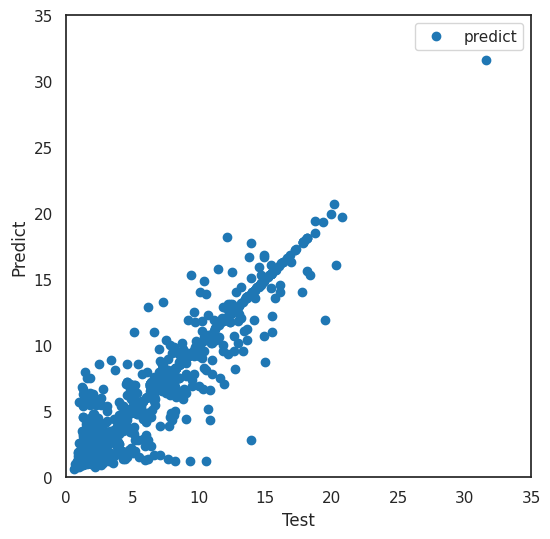

In [22]:
sns.set_context('notebook')
sns.set_style('white')
fig = plt.figure(figsize=(6,6))
ax = plt.axes()

ph_test_predict = pd.DataFrame({'test':y_test.values,
                                'predict': y_test_pred_gr_sugar}).set_index('test').sort_index()

ph_test_predict.plot(marker='o', ls='', ax=ax)
ax.set(xlabel='Test', ylabel='Predict', xlim=(0,35), ylim=(0,35));

## Question 6 

This question requires an additional command line program (GraphViz) and Python library (PyDotPlus). GraphViz can be installed with a package manager on Linux and Mac. For PyDotPlus, either `pip` or `conda` (`conda install -c conda-forge pydotplus`) can be used to install the library.

Once these programs are installed:

* Create a visualization of the decision tree from question 3, where wine color was predicted and the number of features and/or splits are not limited.
* Create a visualization of the decision tree from question 4, where wine color was predicted but a grid search was used to find the optimal depth and number of features.

The decision tree from question 5 will likely have too many nodes to visualize.


In [23]:
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

Visualizing the tree from question 3.


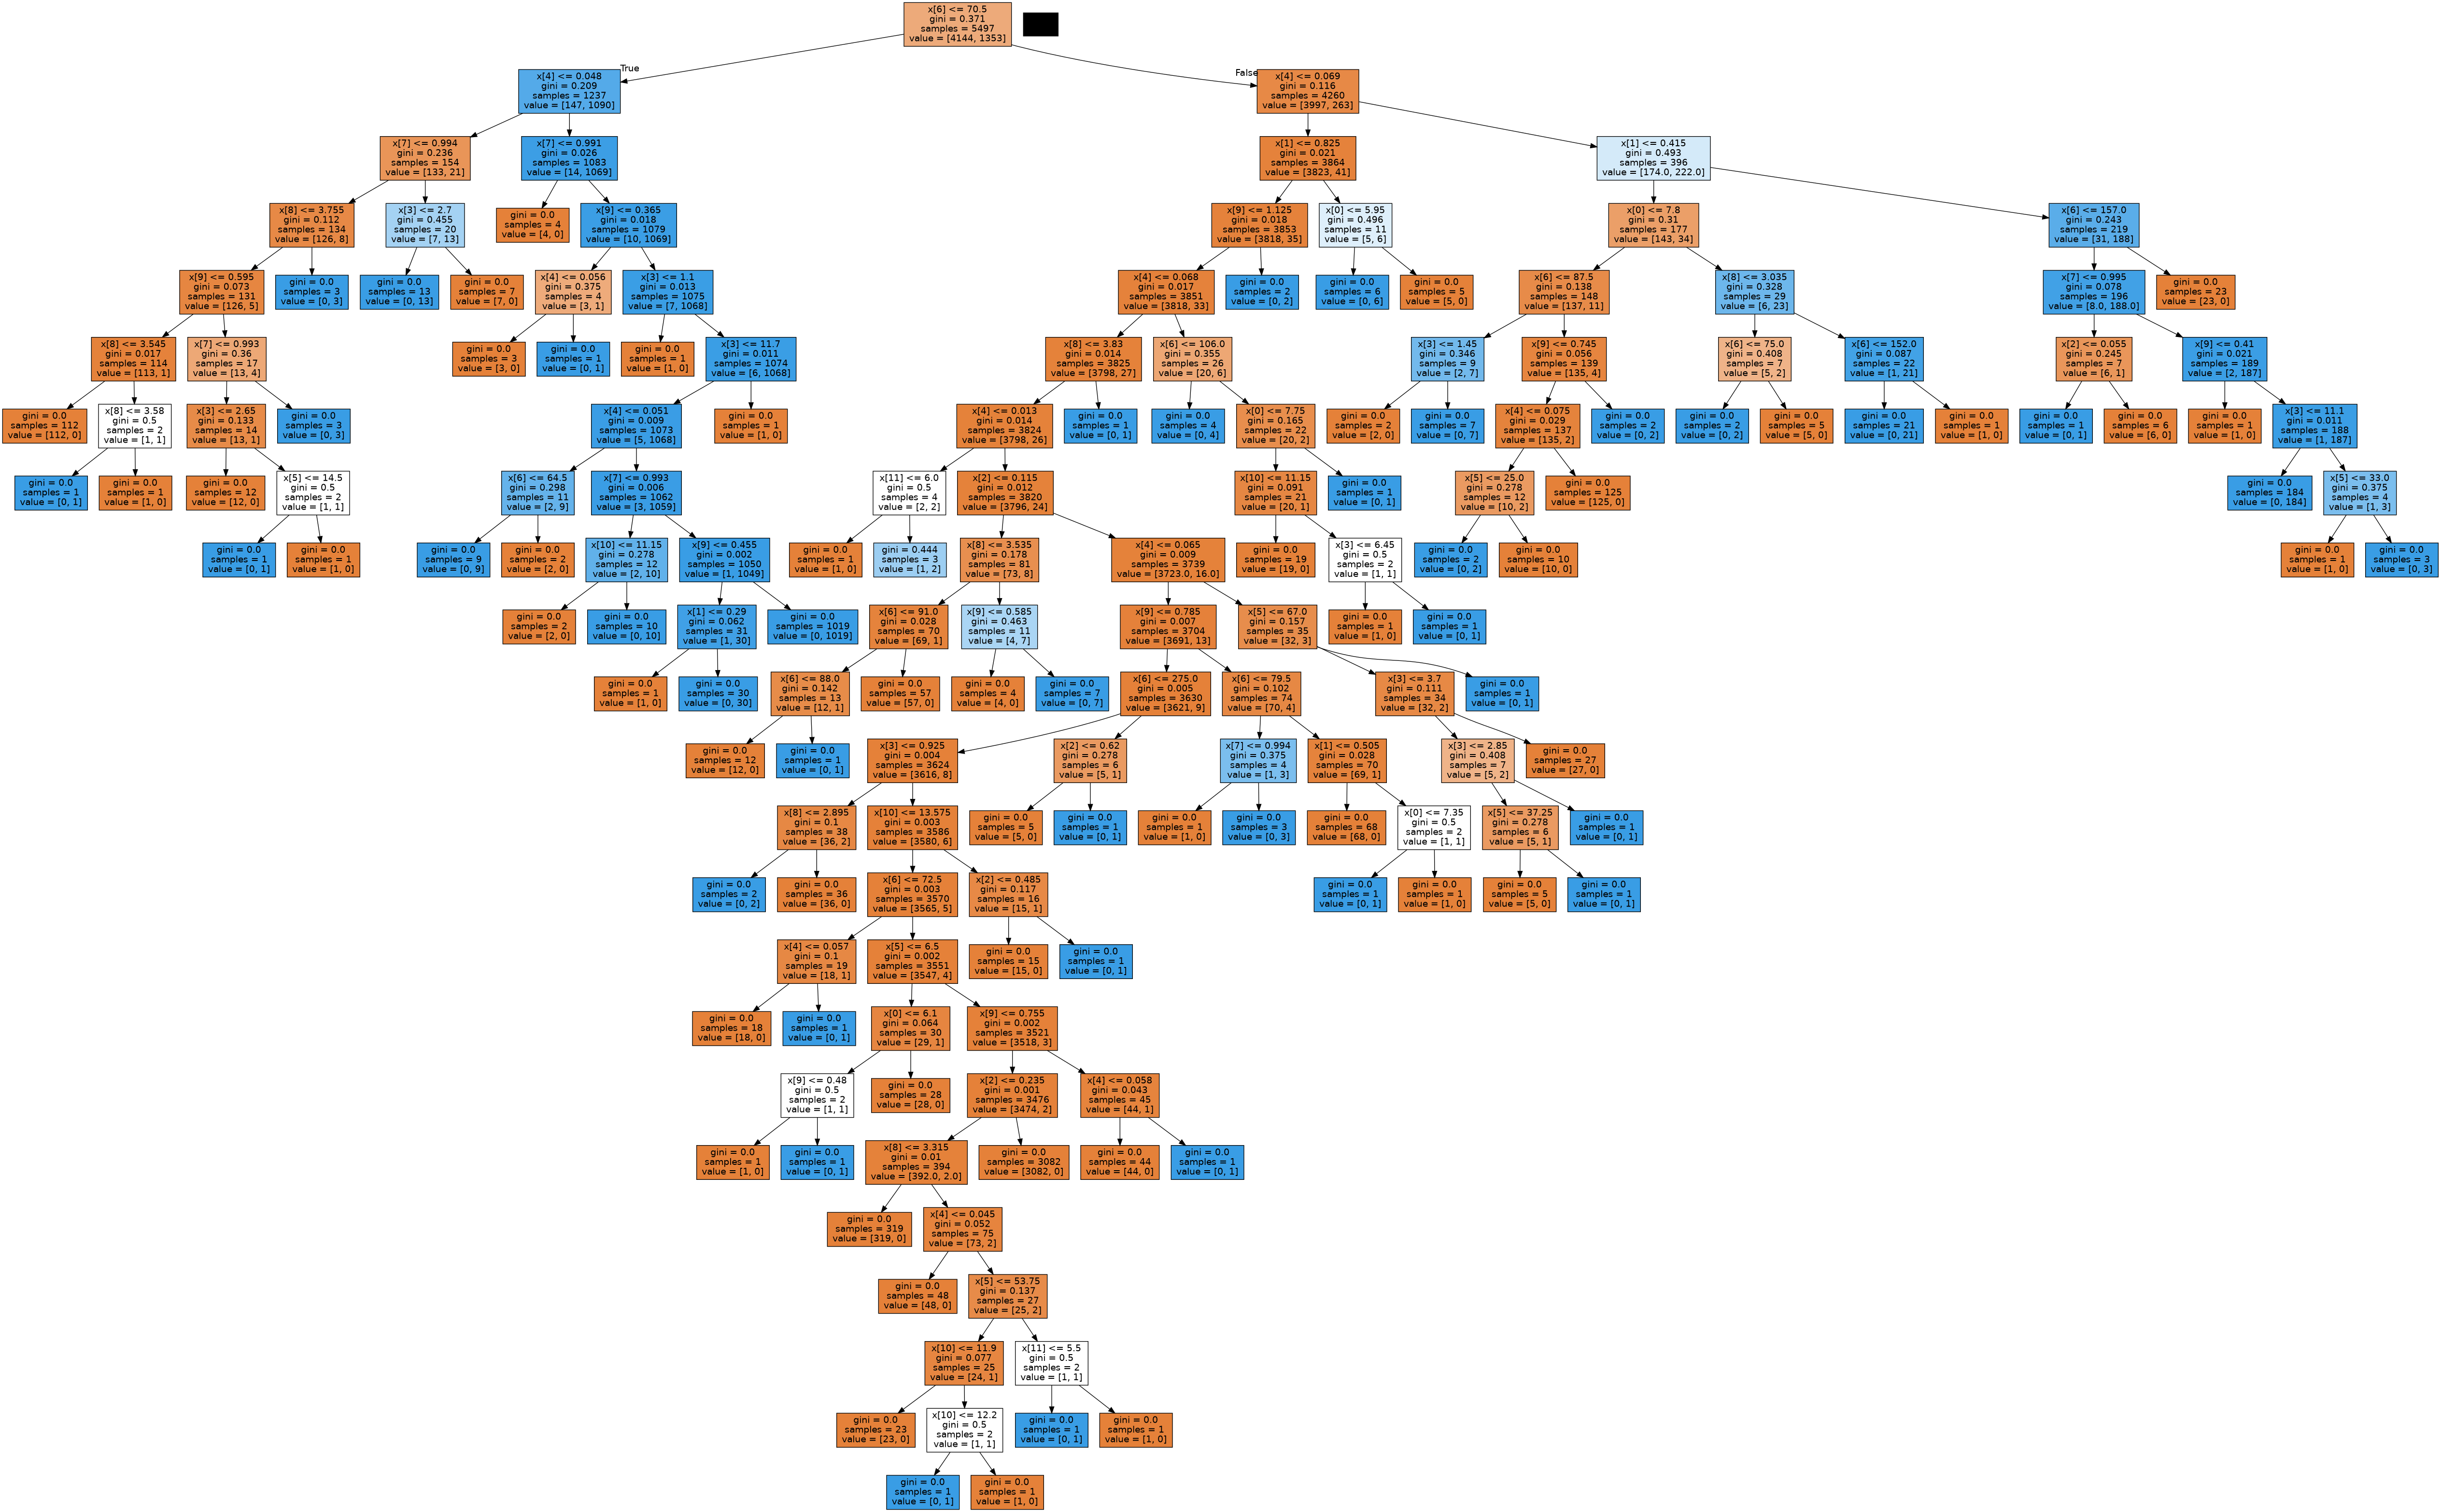

In [24]:
# Create an output destination for the file
dot_data = StringIO()
export_graphviz(dt, out_file=dot_data, filled=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# save & view the tree image
filename = 'wine_tree.png'
graph.write_png(filename)
Image(filename=filename)



The pruned tree fit with cross validation from question 4. This tree is much shallower than the previous one.


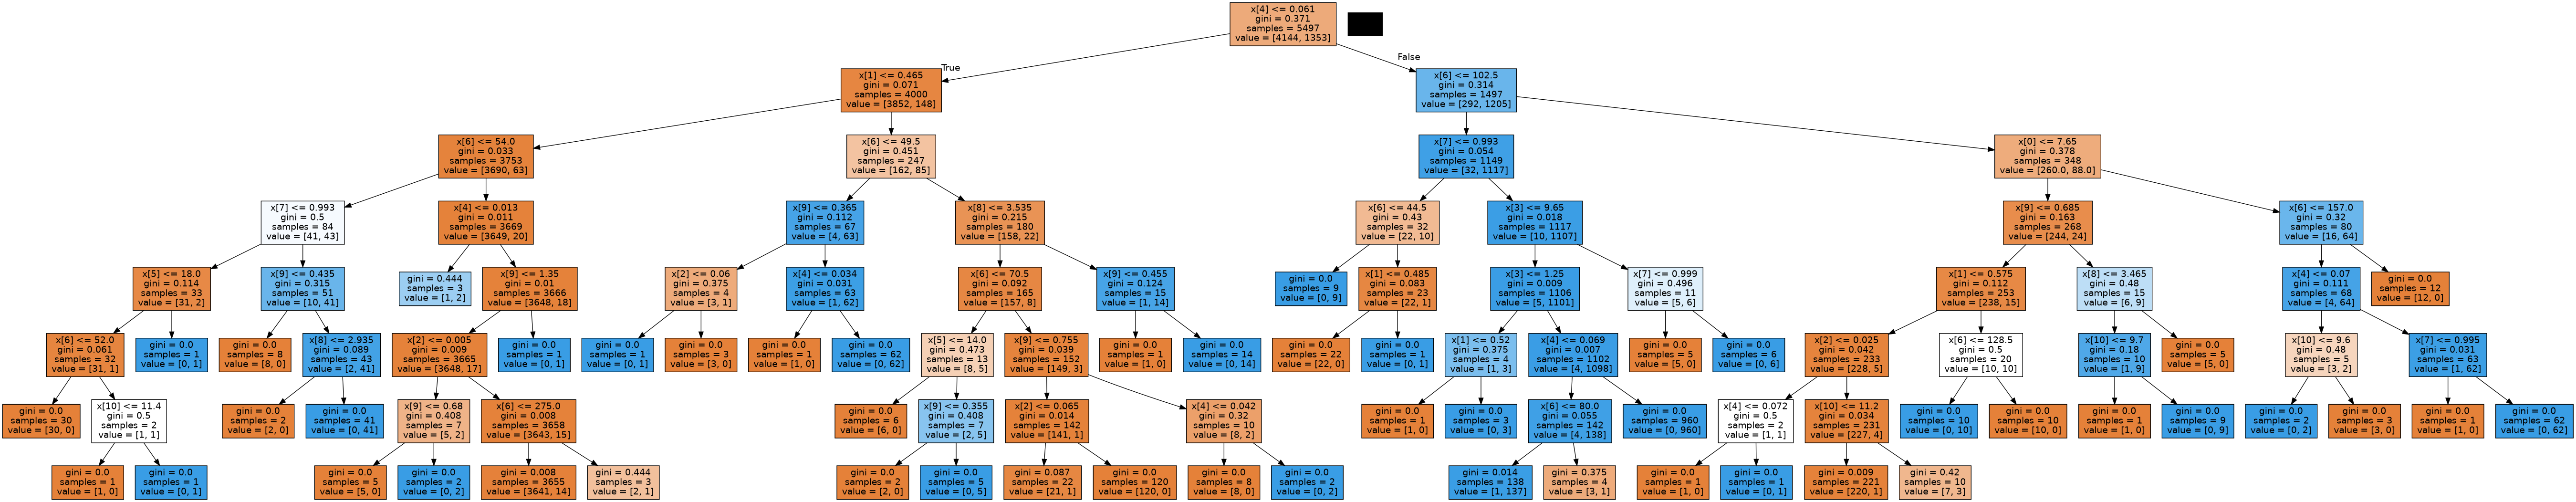

In [25]:
# For the pruned decision tree (assuming `GR` from our GridSearchCV instance)
best_tree = GR.best_estimator_

# Create an output destination for the file
dot_data = StringIO()
export_graphviz(best_tree, out_file=dot_data, filled=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# save & view the tree image
filename = 'wine_tree_prune.png'
graph.write_png(filename)
Image(filename=filename)


We can also visualize the trees using sns and matplitlib, but the details are not as good.

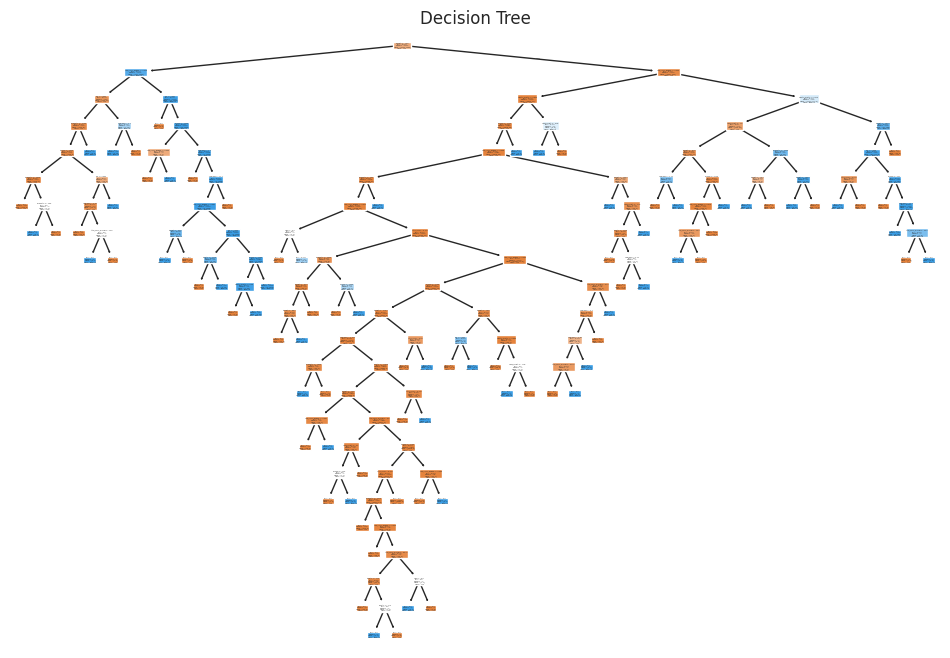

In [26]:
# Tree from question 3.

# Assuming 'data' is your DataFrame and you have already defined the feature columns
feature_cols = [x for x in data.columns if x != 'residual_sugar']  # Adjust this based on your dataset

# For the original decision tree (assuming `dt` is your trained model)
plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True, feature_names=feature_cols, class_names=['Low', 'Medium', 'High'])  # Adjust class names as needed
plt.title('Decision Tree')
plt.savefig('wine_tree_sns.png')  # Save the tree as an image
plt.show()

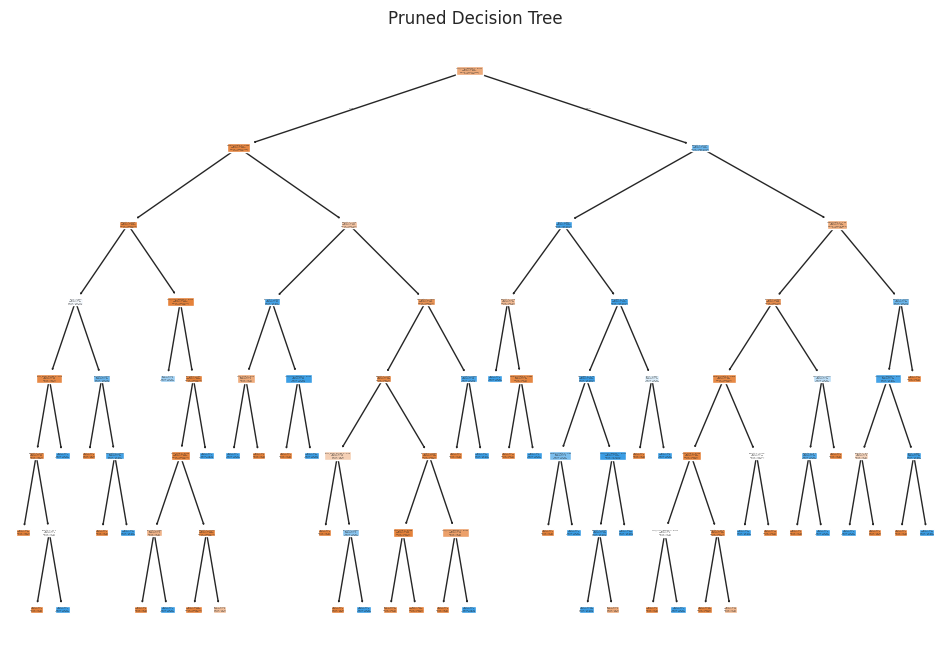

In [27]:
# For the pruned decision tree (assuming `GR` from our GridSearchCV instance)
best_tree = GR.best_estimator_

plt.figure(figsize=(12, 8))
plot_tree(best_tree, filled=True, feature_names=feature_cols, class_names=['Low', 'Medium', 'High'])  # Adjust class names as needed
plt.title('Pruned Decision Tree')
plt.savefig('wine_tree_prune_sns.png')  # Save the pruned tree as an image
plt.show()

---
### Machine Learning Foundation (C) 2020 IBM Corporation
